# 1. Import Libraries

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import StratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, precision_recall_curve
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

import shap
import joblib

import warnings
warnings.filterwarnings('ignore')

# 2. Load Dataset

In [4]:
df = pd.read_csv('credit_risk.csv')

# 3. EDA (Exploratory Data Analysis)

In [5]:
df.head(10)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


In [6]:
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [7]:
df.shape

(32581, 12)

In [8]:
df.size

390972

In [9]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [11]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [12]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [13]:
df.duplicated().sum()

np.int64(165)

In [14]:
df['loan_status'].unique()

array([1, 0])

In [15]:
df['loan_status'].value_counts()

,count
loan_status,
0,25473
1,7108


# 4. Data Visualization

<Axes: ylabel='loan_status'>

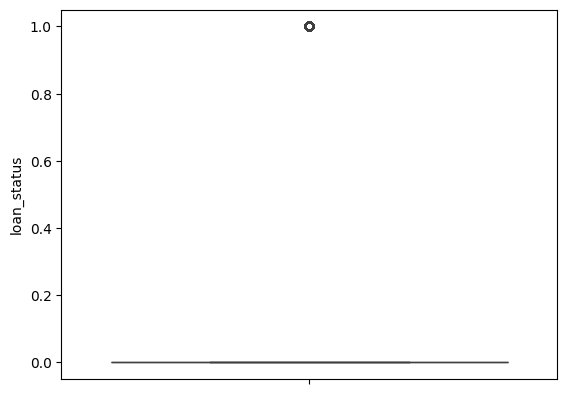

In [16]:
sns.boxplot(df['loan_status'])

<Axes: xlabel='loan_status', ylabel='count'>

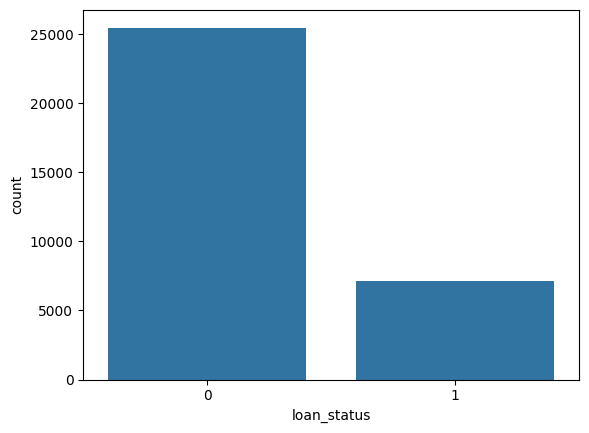

In [17]:
sns.countplot(data=df, x='loan_status')

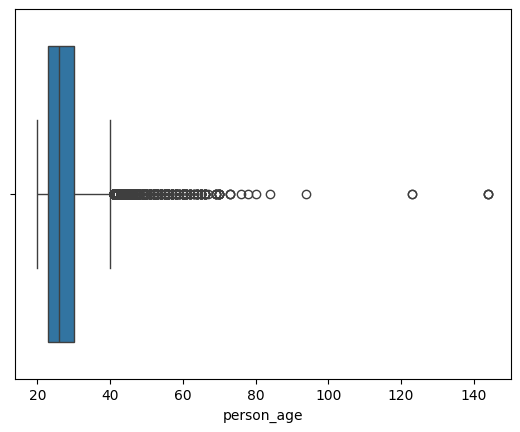

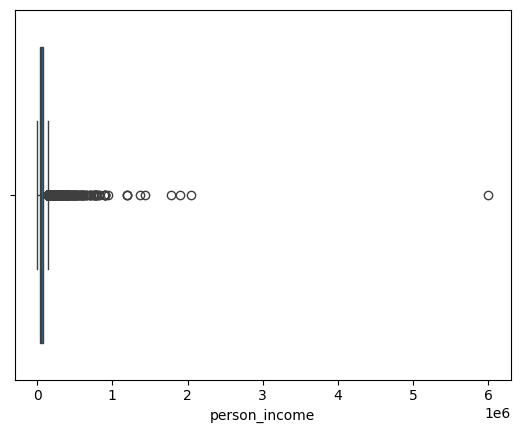

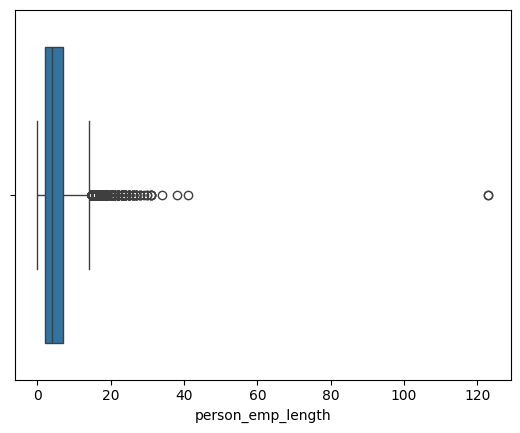

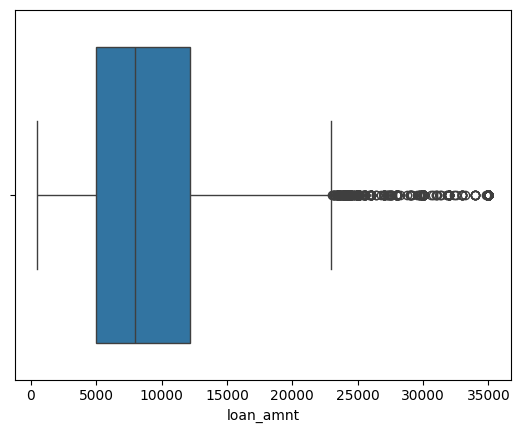

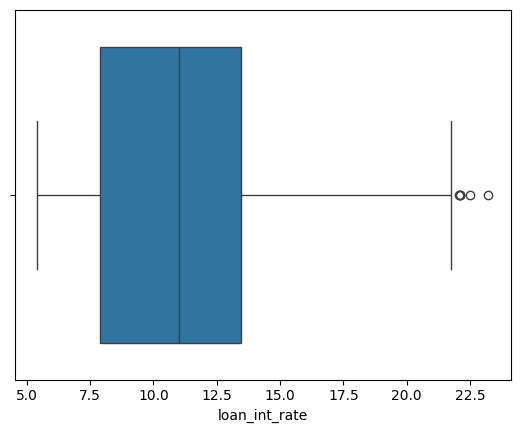

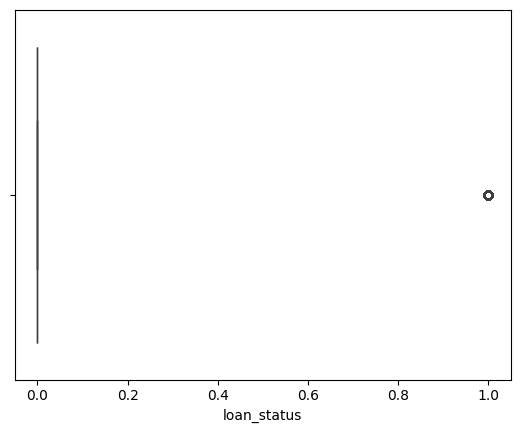

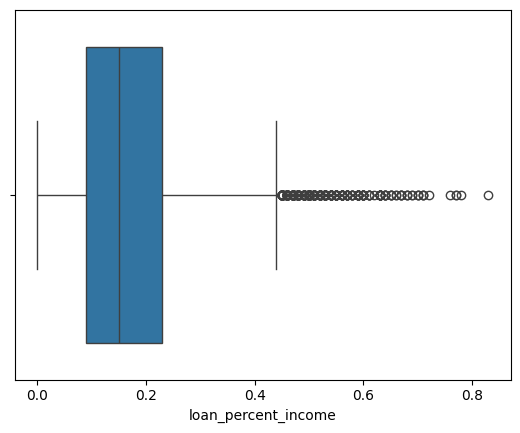

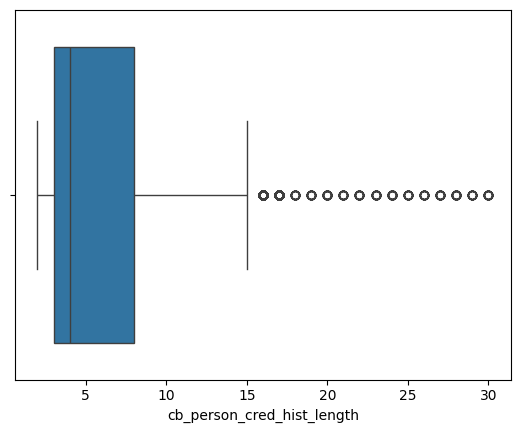

In [18]:
numeric_cols = df.select_dtypes(include='number')
for col in numeric_cols:
  sns.boxplot(x=df[col])
  plt.show()

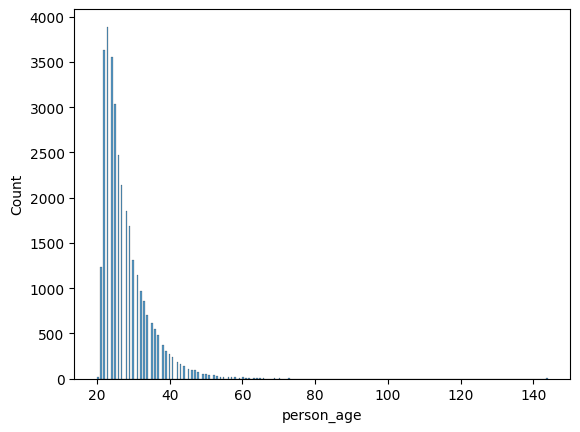

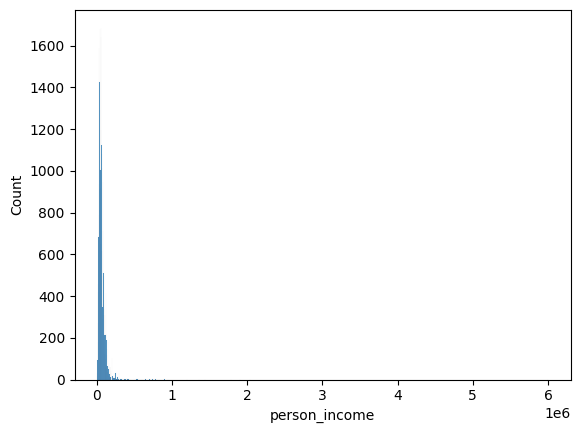

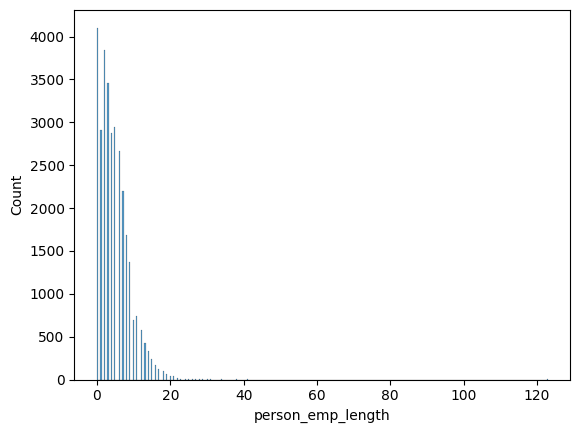

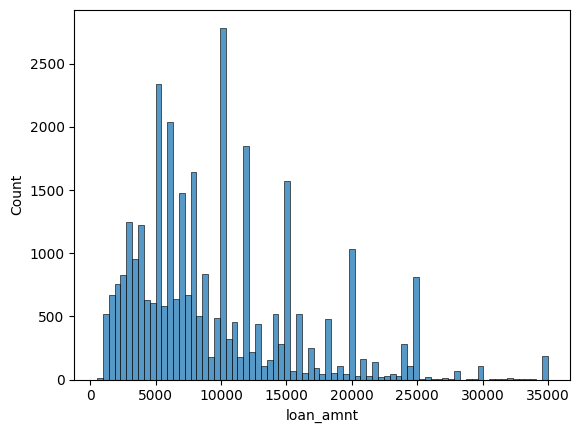

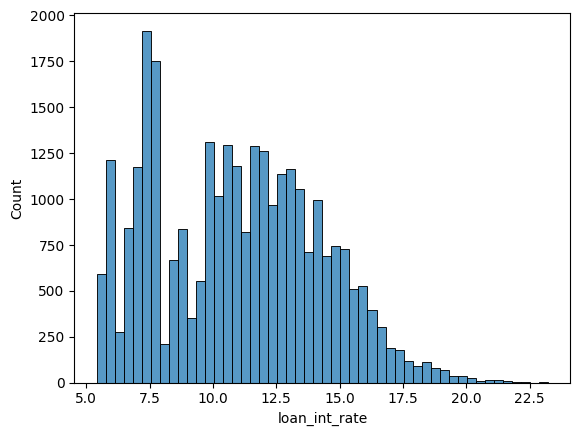

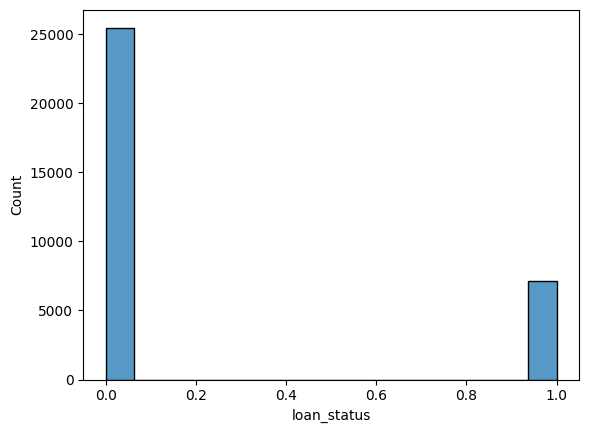

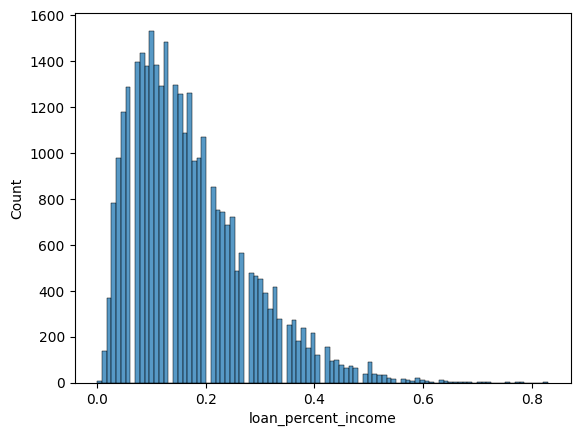

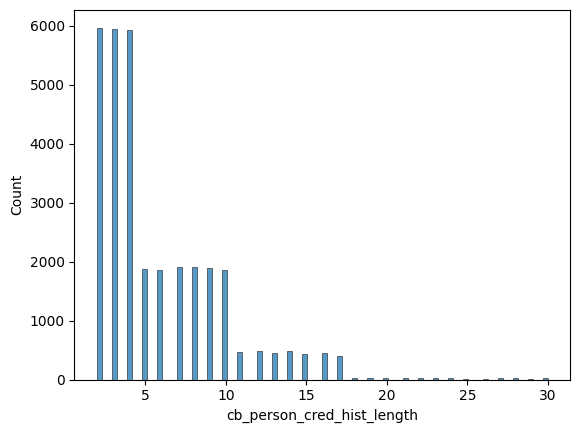

In [19]:
for col in numeric_cols:
  sns.histplot(df[col])
  plt.show()

In [20]:
for col in numeric_cols:
  print(f'Skewness of {col} is  {df[col].skew()}')

Skewness of person_age is  2.5813925261849846
Skewness of person_income is  32.865348833904434
Skewness of person_emp_length is  2.6144551214595424
Skewness of loan_amnt is  1.1924774277661998
Skewness of loan_int_rate is  0.2085503016908977
Skewness of loan_status is  1.3648884873271683
Skewness of loan_percent_income is  1.0646686367683245
Skewness of cb_person_cred_hist_length is  1.6617901199126253


In [21]:
Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1
UF = Q3 + (1.5 * IQR)
LF = Q1 - (1.5 * IQR)

outliers = (numeric_cols > UF) | (numeric_cols < LF)
outliers.sum()

,0
person_age,1494
person_income,1484
person_emp_length,853
loan_amnt,1689
loan_int_rate,6
loan_status,7108
loan_percent_income,651
cb_person_cred_hist_length,1142


In [22]:
(df['person_age'] > 100).sum()

np.int64(5)

In [23]:
(df['person_emp_length'] > 60).sum()

np.int64(2)

<Axes: >

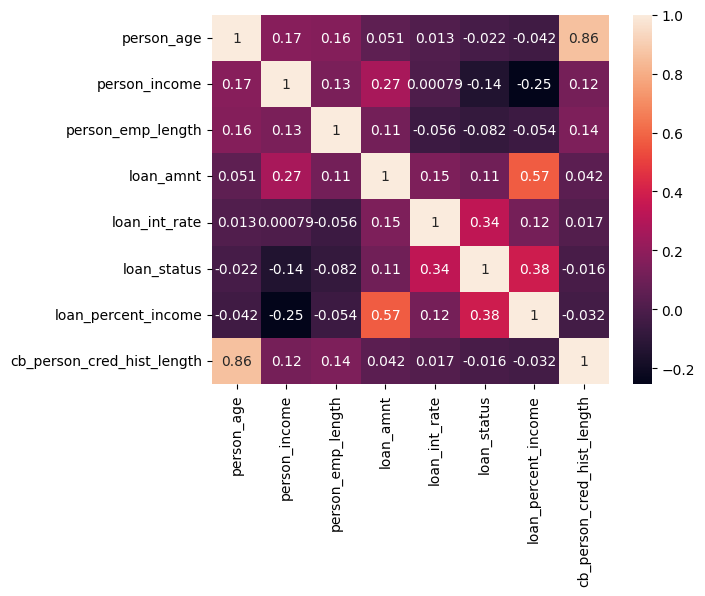

In [24]:
sns.heatmap(df.corr(numeric_only=True), annot=True,)

# 5. Data Cleaning

In [25]:
df_copy = df.copy()

In [26]:
print(f'Original Rows: {df_copy.shape[0]}')

# Remove Duplicates
df_copy.drop_duplicates(inplace=True)

print(f'Rows after removing duplicates: {df_copy.shape[0]}')

# Remove rows bellow age of 18 and above age of 100
df_copy = df_copy[df_copy['person_age'] >= 18]
df_copy = df_copy[df_copy['person_age'] <= 100]

# Remove employment length greater than age or extreme outliers (<60)
df_copy = df_copy[df_copy['person_emp_length'] <= df_copy['person_age']]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

# Remove the rows with zero or negative income and loan amount
df_copy = df_copy[df_copy['loan_amnt'] > 0]

# Check if the interest looks realistic
print(f'Loan interest rate range from (min: 5.42 or max: 23.44)')

Original Rows: 32581
Rows after removing duplicates: 32416
Loan interest rate range from (min: 5.42 or max: 23.44)


# 6. Train Test Split

In [27]:
X = df_copy.drop('loan_status', axis=1)
y = df_copy['loan_status']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [29]:
numeric_cols = ['person_age',	'person_income', 'person_emp_length',
                'loan_amnt',	'loan_int_rate', 'loan_percent_income',
                'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade',
                    'cb_person_default_on_file']

# 7. Handle Class Imbalance

In [30]:
y_train.value_counts()

,count
loan_status,
0,17300
1,4765


In [31]:
neg, pos = np.bincount(y_train)
scale_weights = neg / pos

In [32]:
scale_weights

np.float64(3.6306400839454356)

# 8. Data Preprocessing


## 8.1 Pipeline For Logistic Regression

In [33]:
skew_cols = ['person_income', 'loan_percent_income']
ordinal_cols = ['loan_grade', 'cb_person_default_on_file']
nominal_cols = ['person_home_ownership', 'loan_intent']
normal_cols = ['person_age', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'cb_person_cred_hist_length']

In [34]:
# skew_pipeline = Pipeline(steps=[
#     ('impute', SimpleImputer(strategy='median')),
#     ('log_transform', FunctionTransformer(np.log10)),
#     ('standard_scaler', StandardScaler())
# ])

# ordinal_pipeline = Pipeline(steps=[
#     ('label_encoder', OrdinalEncoder())
# ])

# nominal_pipeline = Pipeline(steps=[
#     ('one_hot_encoder', OneHotEncoder(handle_unknown='ignore'))
# ])

# normal_pipeline = Pipeline(steps=[
#     ('impute', SimpleImputer(strategy='median')),
#     ('standard_scaler', StandardScaler())
# ])

In [35]:
# preprocessor = ColumnTransformer(transformers=[
#     ('skew_preprocessor', skew_pipeline, skew_cols),
#     ('ordinal_preprocessor', ordinal_pipeline, ordinal_cols),
#     ('nominal_preprocessor', nominal_pipeline, nominal_cols),
#     ('normal_preprocessor', normal_pipeline, normal_cols)
# ])

In [36]:
lr_numeric_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('standard_scaler', StandardScaler())
])
lr_cat_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='constant', fill_value='missing')),
    ('one_hot_encoding', OneHotEncoder())
])

In [37]:
lr_preprocessor = ColumnTransformer(transformers=[
    ('numeric_pipeline', lr_numeric_pipeline, numeric_cols),
    ('categorical_pipeline', lr_cat_pipeline, categorical_cols)
])

In [38]:
X_train_transform = lr_preprocessor.fit_transform(X_train)

In [39]:
X.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3027
loan_percent_income,0
cb_person_default_on_file,0


## 8.2 Pipeline For XGBoost

In [40]:
xgb_num_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median'))
])

xgb_cat_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='constant', fill_value='missing')),
    ('one_hot_encoding', OneHotEncoder(handle_unknown='ignore'))
])

In [41]:
xgb_preprocessor = ColumnTransformer(transformers=[
    ('numeric_cols', xgb_num_pipeline, numeric_cols),
    ('categorical_cols', xgb_cat_pipeline, categorical_cols)
])

# 9. Apply Cross Validation

In [42]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [43]:
scoring = {
    'roc_auc': 'roc_auc',
    'recall': 'recall',
    'accuracy': 'accuracy',
    'precision': 'precision',
    'f1_score': 'f1'
    }

# 10. Train Model

## 10.1 For Logistic Regression

In [44]:
# This is a baseline model
lr_pipeline = Pipeline(steps=[
    ('preprocessor', lr_preprocessor),
    ('logistic_regression', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

In [45]:
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standard_scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('categorical_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('one_hot_encoding',
                                                                   OneHotEncoder())]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('logistic_regression',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

## 10.2 For Decision Tree

In [46]:
tree_pipeline = Pipeline(steps=[
    ('preprocessor', lr_preprocessor),
    ('decision_tree',DecisionTreeClassifier(
        class_weight='balanced',
        max_depth=7,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
    ))
])

In [47]:
tree_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standard_scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('categorical_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('one_hot_encoding',
                                                                   OneHotEncoder())]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('decision_tree',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=7,
                                        min_samples_leaf=5,
                                        min_samples_split=10,
                                        random_state=42))])

## 10.3 For XGBoost

In [48]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', xgb_preprocessor),
    ('xgboost', XGBClassifier(
        n_estimator=300,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        scale_pos_weight=scale_weights
    ))
])

In [49]:
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric_cols',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('categorical_cols',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='missi...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimator=300, n_estimators=None, n_jobs=None, ...))])

## 10.4 For Random Forest

In [50]:
forest_pipeline = Pipeline(steps=[
    ('preprocessor', xgb_preprocessor),
    ('random_forest', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        n_jobs=-1
    ))
])

In [51]:
forest_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric_cols',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('categorical_cols',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('one_hot_encoding',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('random_forest',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_leaf=2, min_samples_split=5,
                                        n_estimators=300, n_jobs=-1))])

## 10.5 For AdaBoost

In [52]:
ada_pipeline = Pipeline(steps=[
    ('preprocessor', xgb_preprocessor),
    ('adaboost', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=50,
        learning_rate=0.1,
        random_state=42
    ))
])

In [53]:
ada_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric_cols',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('categorical_cols',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('one_hot_encoding',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('adaboost',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=42),
                                    learning_rate=0.1, random_state=42))])

# 11. Cross Validation

In [54]:
for model_name, pipe in [('Logistic Regression', lr_pipeline), ('XGBoost', xgb_pipeline),
  ('Decision Tree', tree_pipeline), ('Random Forest', forest_pipeline), ('AdaBoost', ada_pipeline)]:
  results = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

  print(model_name)
  print(f'ROC_AUC {results['test_roc_auc'].mean()}')
  print(f'Accuracy {results['test_accuracy'].mean()}')
  print(f'Precision {results['test_precision'].mean()}')
  print(f'Recall {results['test_recall'].mean()}')
  print(f'F1 Score {results['test_f1_score'].mean()}')

Logistic Regression
ROC_AUC 0.8710636929926183
Accuracy 0.8117380466802627
Precision 0.5454408514974111
Recall 0.7769150052465897
F1 Score 0.6407615886048793
XGBoost
ROC_AUC 0.9394313970485658
Accuracy 0.9082710174484477
Precision 0.7888144537486663
Recall 0.785729275970619
F1 Score 0.787176255069968
Decision Tree
ROC_AUC 0.8981196586380701
Accuracy 0.9065035123498755
Precision 0.8311218552160378
Recall 0.7139559286463799
F1 Score 0.7674485049406543
Random Forest
ROC_AUC 0.9239766723883811
Accuracy 0.9124405166553367
Precision 0.8336664269410914
Recall 0.7433368310598111
F1 Score 0.7857779632227622
AdaBoost
ROC_AUC 0.8392693289824044
Accuracy 0.8860185814638568
Precision 0.7266623382188973
Recall 0.7569779643231899
F1 Score 0.7415033026145691


In [55]:
results

{'fit_time': array([0.41058326, 0.33421493, 0.48250985, 0.49799109, 0.24753261]),
 'score_time': array([0.09095263, 0.06571221, 0.10213208, 0.13730168, 0.0499475 ]),
 'test_roc_auc': array([0.82448671, 0.84164943, 0.8420452 , 0.84255424, 0.84561106]),
 'test_recall': array([0.73452256, 0.76075551, 0.75865687, 0.76285414, 0.76810073]),
 'test_accuracy': array([0.87559483, 0.8876048 , 0.88941763, 0.88783141, 0.88964423]),
 'test_precision': array([0.70281124, 0.73011078, 0.73700306, 0.72991968, 0.73346693]),
 'test_f1_score': array([0.71831709, 0.74511819, 0.74767322, 0.7460236 , 0.75038442])}

# 12. Model Evaluation

## 12.1 Evaluation Function

In [56]:
def model_evaluation(model_name, model, X_test, y_test, threshold=None):
  # y_pred = model.predict(X_test)
  y_pred_prob = model.predict_proba(X_test)[:,1]

  if threshold is not None:
    y_pred = (y_pred_prob > threshold).astype(int)
  else:
    y_pred = model.predict(X_test)

  # Metrics for evaluation
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)

  # Confusion Metrics
  confusion = confusion_matrix(y_test, y_pred)
  classification = classification_report(y_test, y_pred)

  # Print Metrics
  print(f'accuracy : {accuracy: .3f}')
  print(f'precision : {precision: .3f}')
  print(f'recall : {recall: .3f}')
  print(f'f1_score : {f1: .3f}')
  print()
  print(f'confusion metrics : {confusion}')
  print(f'classification report : {classification}')

  # Plot confusion metrics
  sns.heatmap(confusion, annot=True, fmt='d')
  plt.title(f'{model_name} Confusion Metrics')
  plt.xlabel('Predicted Values')
  plt.ylabel('Actual Values')
  plt.show()

  # Plotting ROC-AUC Curve
  precisions, recalls, threshold = precision_recall_curve(y_test, y_pred_prob)
  plt.plot(precisions, recalls)
  plt.xlabel('Recall')
  plt.ylabel('Precision')
  plt.title(f'{model_name} Precision Recall Curve')
  plt.show()

 ## 12.2 Apply Evaluation Function

accuracy :  0.816
precision :  0.552
recall :  0.784
f1_score :  0.648

confusion metrics : [[6116 1299]
 [ 441 1601]]
classification report :               precision    recall  f1-score   support

           0       0.93      0.82      0.88      7415
           1       0.55      0.78      0.65      2042

    accuracy                           0.82      9457
   macro avg       0.74      0.80      0.76      9457
weighted avg       0.85      0.82      0.83      9457



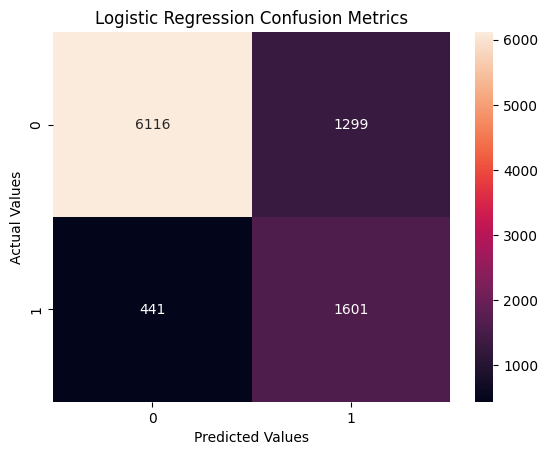

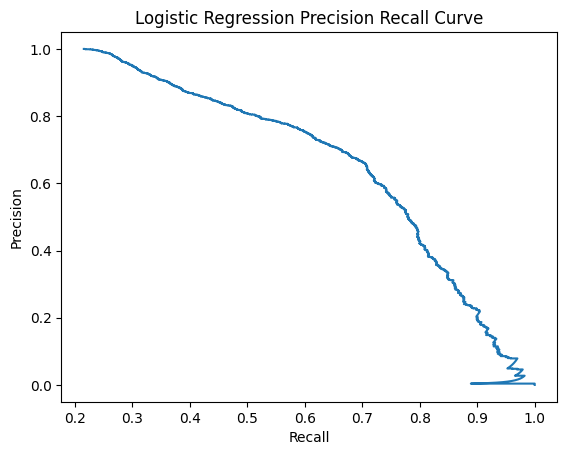

In [57]:
model_evaluation('Logistic Regression', lr_pipeline, X_test, y_test)

accuracy :  0.909
precision :  0.789
recall :  0.788
f1_score :  0.789

confusion metrics : [[6984  431]
 [ 432 1610]]
classification report :               precision    recall  f1-score   support

           0       0.94      0.94      0.94      7415
           1       0.79      0.79      0.79      2042

    accuracy                           0.91      9457
   macro avg       0.87      0.87      0.87      9457
weighted avg       0.91      0.91      0.91      9457



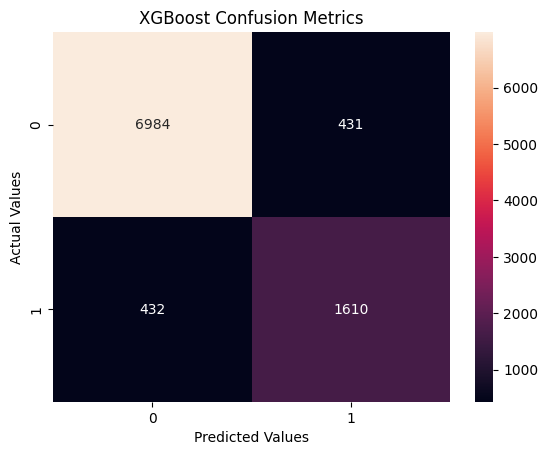

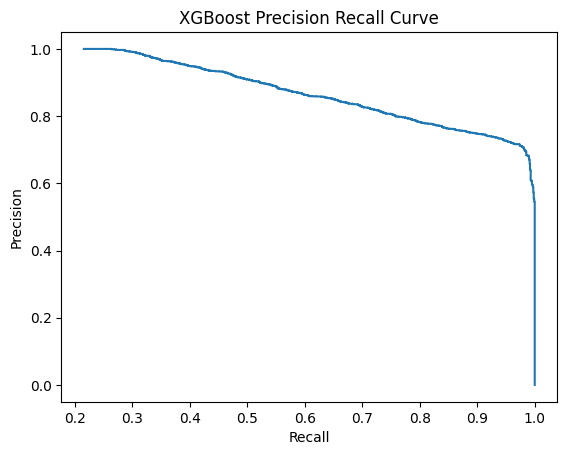

In [58]:

model_evaluation('XGBoost', xgb_pipeline, X_test, y_test)

accuracy :  0.906
precision :  0.812
recall :  0.734
f1_score :  0.771

confusion metrics : [[7069  346]
 [ 544 1498]]
classification report :               precision    recall  f1-score   support

           0       0.93      0.95      0.94      7415
           1       0.81      0.73      0.77      2042

    accuracy                           0.91      9457
   macro avg       0.87      0.84      0.86      9457
weighted avg       0.90      0.91      0.90      9457



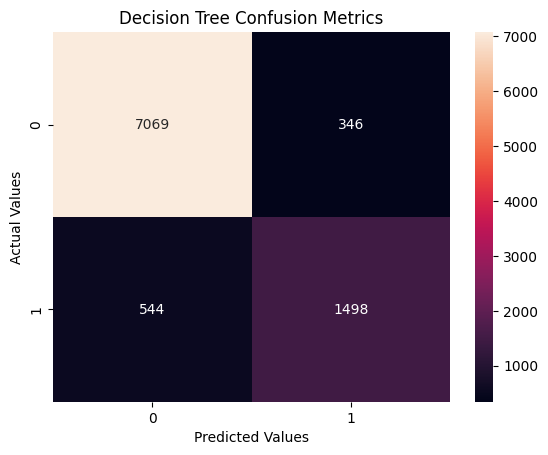

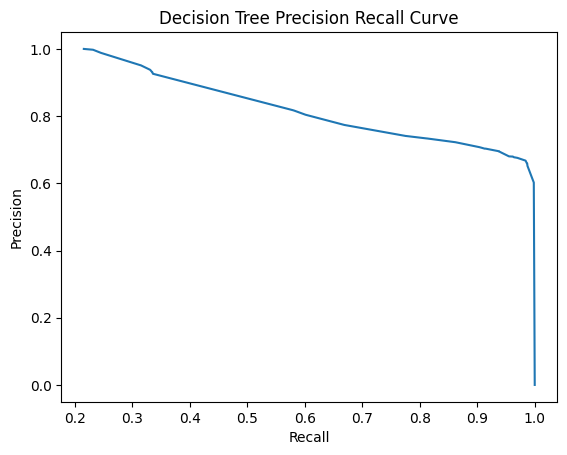

In [59]:
model_evaluation('Decision Tree', tree_pipeline, X_test, y_test)

accuracy :  0.914
precision :  0.838
recall :  0.747
f1_score :  0.790

confusion metrics : [[7120  295]
 [ 517 1525]]
classification report :               precision    recall  f1-score   support

           0       0.93      0.96      0.95      7415
           1       0.84      0.75      0.79      2042

    accuracy                           0.91      9457
   macro avg       0.89      0.85      0.87      9457
weighted avg       0.91      0.91      0.91      9457



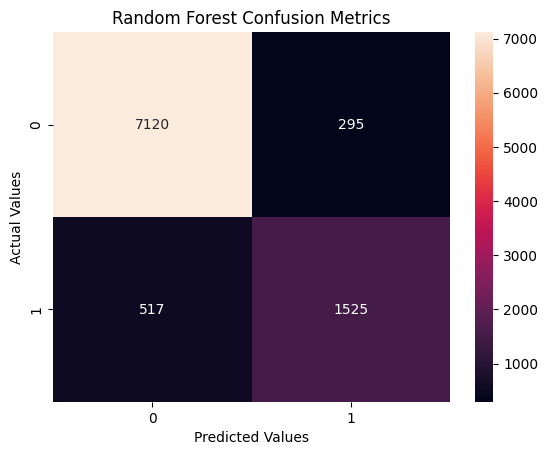

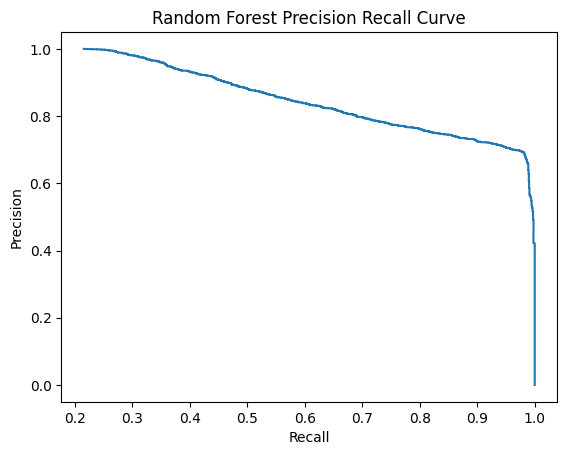

In [60]:
model_evaluation('Random Forest', forest_pipeline, X_test, y_test)

accuracy :  0.885
precision :  0.721
recall :  0.759
f1_score :  0.740

confusion metrics : [[6817  598]
 [ 493 1549]]
classification report :               precision    recall  f1-score   support

           0       0.93      0.92      0.93      7415
           1       0.72      0.76      0.74      2042

    accuracy                           0.88      9457
   macro avg       0.83      0.84      0.83      9457
weighted avg       0.89      0.88      0.89      9457



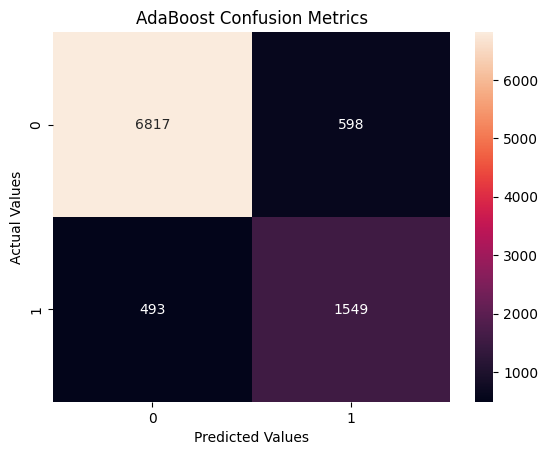

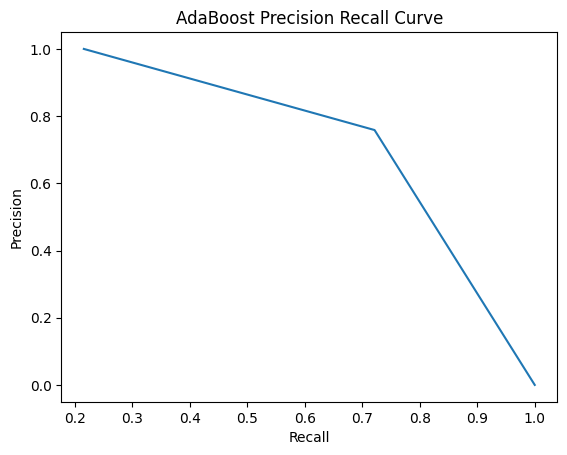

In [61]:
model_evaluation('AdaBoost', ada_pipeline, X_test, y_test)

# 13. Hyperparameter Tuning

## 13.1 For XGBoost

In [62]:
xgb_param_grid = {
    'xgboost__n_estimators': randint(150, 600), # Number of decision trees
    'xgboost__max_depth': randint(3, 9), # Maximum depth of the model
    'xgboost__learning_rate': uniform(0.01, 0.5), # Learning rate of the model
    'xgboost__subsample': uniform(0.6, 0.4), # Rows Sampling/Shuffling
    'xgboost__colsample_bytree': uniform(0.6, 0.4), #  Columns Sampling/Shuffling
    'xgboost__min_child_weight': randint(1, 10),
    'xgboost__gamma': uniform(0, 5)
}

# lower gamma -> more splits -> complex tree -> higher overfitting risk
# higher gamma -> less splits -> simple tree -> lower overfitting risk

In [63]:
xgb_random_search = RandomizedSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    n_iter=20,
    cv=cv,
    n_jobs=-1,
    scoring='average_precision',
    verbose=1
)

In [64]:
xgb_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numeric_cols',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_his...
                                        'xgboost__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f509bdfdd10>,
                                        'xgboost__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f509bdfe490>,
                                        'xgboost__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f50a5ec74d0>,
                                        'xgboost__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f509bdfe0d0>},
                   scoring='average_precision', verbose=1)

In [65]:
xgb_random_search.best_params_

{'xgboost__colsample_bytree': np.float64(0.7070417383326294),
 'xgboost__gamma': np.float64(2.357822394294469),
 'xgboost__learning_rate': np.float64(0.13738838721153734),
 'xgboost__max_depth': 7,
 'xgboost__min_child_weight': 9,
 'xgboost__n_estimators': 368,
 'xgboost__subsample': np.float64(0.8597848527163603)}

In [66]:
xgb_random_search.best_score_

np.float64(0.9004872810932028)

## 13.2 For Decision Tree


In [67]:
tree_param_grid = {
    'decision_tree__max_depth': [3, 5, 7, 10, 15, 20],
    'decision_tree__min_samples_split': [2, 5, 10, 20],
    'decision_tree__min_samples_leaf': [1, 2, 5, 10],
    'decision_tree__criterion': ['gini', 'entropy', 'log_loss'],
    'decision_tree__class_weight': [None, 'balanced']
}

In [68]:
tree_random_search = RandomizedSearchCV(
    tree_pipeline,
    tree_param_grid,
    n_iter=20,
    cv=cv,
    n_jobs=-1,
    scoring='average_precision',
    verbose=1
)

In [69]:
tree_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numeric_pipeline',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('standard_scaler',
                                                                                                StandardScaler())]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',...
                                                                     min_samples_split=10,
                                                                     random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'decision_tree__class_weight': [None,
                                                                        'balanced'],
                                        'decision_tree__criterion': ['gini',
                                                                     'entropy',
                                                                     'log_loss'],
                                        'decision_tree__max_depth': [3, 5, 7,
                                                                     10, 15,
                                                                     20],
                                        'decision_tree__min_samples_leaf': [1,
                                                                            2,
                                                                            5,
                                                                            10],
                                        'decision_tree__min_samples_split': [2,
                                                                             5,
                                                                             10,
                                                                             20]},
                   scoring='average_precision', verbose=1)

In [70]:
tree_random_search.best_params_

{'decision_tree__min_samples_split': 20,
 'decision_tree__min_samples_leaf': 10,
 'decision_tree__max_depth': 15,
 'decision_tree__criterion': 'entropy',
 'decision_tree__class_weight': 'balanced'}

In [71]:
tree_random_search.best_score_

np.float64(0.8437833583259546)

## 13.3 For Random Forest

In [72]:
forest_param_grid = {
    'random_forest__n_estimators': [100, 200, 300],
    'random_forest__max_depth': [10, 20, None],
    'random_forest__min_samples_split': [2, 5, 10],
    'random_forest__min_samples_leaf': [1, 2, 5, 10],
    'random_forest__class_weight': [None, 'balance'],
    'random_forest__max_features': ['sqrt', 'log2']
}

In [73]:
forest_random_search = RandomizedSearchCV(
    forest_pipeline,
    forest_param_grid,
    n_iter= 20,
    cv=cv,
    n_jobs=-1,
    scoring='average_precision',
    verbose=1,
    random_state=42
)

In [74]:
forest_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numeric_cols',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_his...
                   n_iter=20, n_jobs=-1,
                   param_distributions={'random_forest__class_weight': [None,
                                                                        'balance'],
                                        'random_forest__max_depth': [10, 20,
                                                                     None],
                                        'random_forest__max_features': ['sqrt',
                                                                        'log2'],
                                        'random_forest__min_samples_leaf': [1,
                                                                            2,
                                                                            5,
                                                                            10],
                                        'random_forest__min_samples_split': [2,
                                                                             5,
                                                                             10],
                                        'random_forest__n_estimators': [100,
                                                                        200,
                                                                        300]},
                   random_state=42, scoring='average_precision', verbose=1)

In [75]:
forest_random_search.best_params_

{'random_forest__n_estimators': 200,
 'random_forest__min_samples_split': 5,
 'random_forest__min_samples_leaf': 1,
 'random_forest__max_features': 'sqrt',
 'random_forest__max_depth': None,
 'random_forest__class_weight': None}

In [76]:
forest_random_search.best_score_

np.float64(0.8805586365925668)

## 13.4 For AdaBoost

In [77]:
ada_param_grid = {
    'adaboost__n_estimators': [50, 100, 150, 200, 300],
    'adaboost__learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0, 1.5],
    'adaboost__estimator__max_depth':  [1, 2, 3, 4, 5],
    'adaboost__estimator__min_samples_split': [2, 5, 10, 20],
    'adaboost__estimator__min_samples_leaf': [1, 2, 5, 10]
}

In [78]:
ada_random_search = RandomizedSearchCV(
    ada_pipeline,
    ada_param_grid,
    n_iter=20,
    cv=cv,
    scoring='average_precision',
    n_jobs=-1
)

In [80]:
ada_random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numeric_cols',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_his...
                                                                 learning_rate=0.1,
                                                                 random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'adaboost__estimator__max_depth': [1, 2,
                                                                           3, 4,
                                                                           5],
                                        'adaboost__estimator__min_samples_leaf': [1,
                                                                                  2,
                                                                                  5,
                                                                                  10],
                                        'adaboost__estimator__min_samples_split': [2,
                                                                                   5,
                                                                                   10,
                                                                                   20],
                                        'adaboost__learning_rate': [0.01, 0.05,
                                                                    0.1, 0.5,
                                                                    1.0, 1.5],
                                        'adaboost__n_estimators': [50, 100, 150,
                                                                   200, 300]},
                   scoring='average_precision')

In [81]:
ada_random_search.best_params_

{'adaboost__n_estimators': 200,
 'adaboost__learning_rate': 1.5,
 'adaboost__estimator__min_samples_split': 10,
 'adaboost__estimator__min_samples_leaf': 10,
 'adaboost__estimator__max_depth': 4}

In [82]:
ada_random_search.best_score_

np.float64(0.8878791966890864)

# 14. Optimizing The Classification Threshold

accuracy :  0.784
precision :  0.000
recall :  0.000
f1_score :  0.000

confusion metrics : [[7415    0]
 [2042    0]]
classification report :               precision    recall  f1-score   support

           0       0.78      1.00      0.88      7415
           1       0.00      0.00      0.00      2042

    accuracy                           0.78      9457
   macro avg       0.39      0.50      0.44      9457
weighted avg       0.61      0.78      0.69      9457



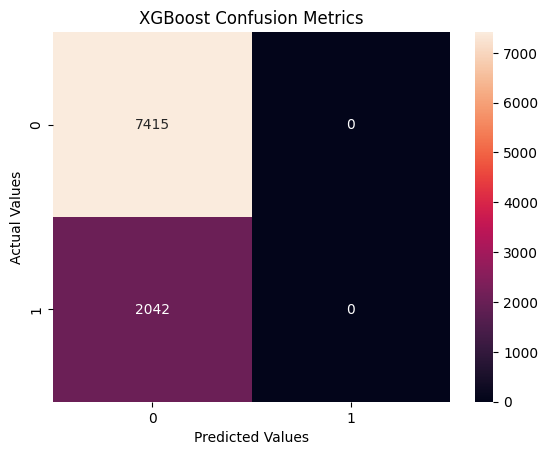

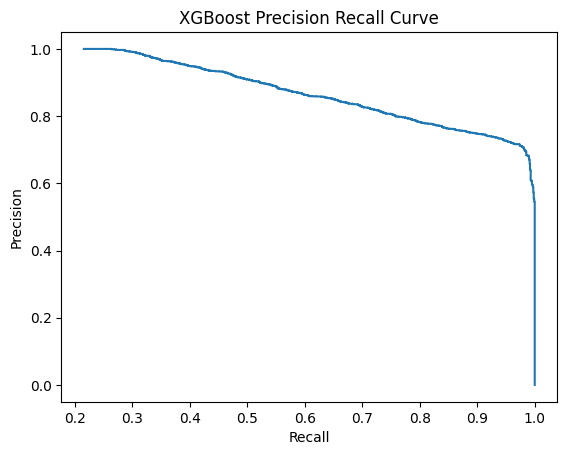

In [104]:
# Get the probability of class 1 from xgboost
prob = xgb_pipeline.predict_proba(X_test)[:, 1]

# For each threshold calculate precision and recall
precisions, recalls, thresholds = precision_recall_curve(y_test, prob)

# Calculate f1 score for each threshold
f1 = 2 * (precisions - recalls) / (precisions + recalls + 1e-9)

# Get the threshold that produces the highest f1 score
best = np.argmax(f1[:-1])
best_threshold = thresholds[best]

# Evaluate the xgboost model with best threshold

model_evaluation('XGBoost', xgb_pipeline, X_test, y_test, best_threshold)

# 15. Probability Calibration

In [84]:
# Methods by which we can fix the poorly calibrated models.
# 1: Platt Scalling / Sigmoid -> Adjust the probabilities using a sigmoid curve.
# 2: Isotonic Regression -> learn a flexible  mapping from old probability - better probability (non-linear calibration).
# 3: Temperature Scaling -> Adjust the confidenc of a neural-network predictions using one temperature.

In [85]:
# 1. Calibrate XGBoost Model.
best_model = xgb_random_search.best_estimator_
calibration_model = CalibratedClassifierCV(
    best_model,
    method='sigmoid',
    cv=5
)

calibration_model.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('numeric_cols',
                                                                                   Pipeline(steps=[('impute',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_length',
                                                                                    'loan_amnt',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_hist_length']),
                                                                                  ('categorical_cols',
                                                                                   Pipeline(steps=[('i...
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=np.float64(0.13738838721153734),
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=7,
                                                                max_leaves=None,
                                                                min_child_weight=9,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimator=300,
                                                                n_estimators=368,
                                                                n_jobs=None, ...))]))

In [86]:
# 2. Get Probabilities.
uncalibrated = xgb_pipeline.predict_proba(X_test)[:, 1]
calibrated = calibration_model.predict_proba(X_test)[:, 1]

In [87]:
# 3. Create calibration curves.
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)

actual_calibrated, predicted_calibrated = calibration_curve(y_test, calibrated, n_bins=10)

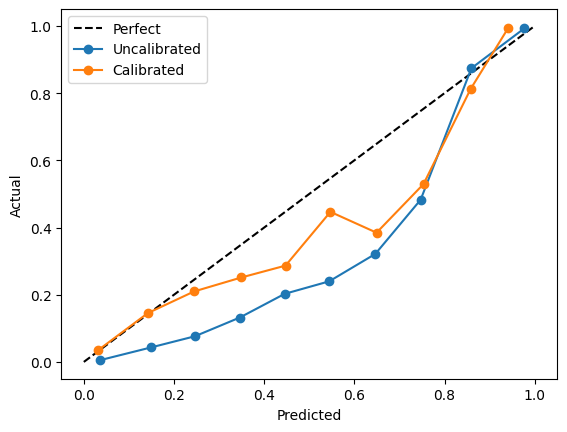

In [88]:
# 4. Plot.
plt.plot([0,1], [0, 1], 'k--', label='Perfect')
plt.plot(
    predicted_uncal,
    actual_uncal,
    'o-',
    label='Uncalibrated',
)
plt.plot(
    predicted_calibrated,
    actual_calibrated,
    'o-',
    label='Calibrated'
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.legend()
plt.show()

In [107]:
# 1. Get the probability from calibrated model.
calibrated_prob = calibration_model.predict_proba(X_test)[:, 1]

# 2. Re-run the same threshold search, now on the correct probability scale.
precisions, recalls, thresholds = precision_recall_curve(y_test, calibrated_prob)

f1 = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold = thresholds[np.argmax(f1[:-1])]

print(f'best threshold : {best_threshold}')

best threshold : 0.5239624914306517


# 16. SHAP Interpretation - Global & Local

In [89]:
# 1. Import SHAP

In [90]:
# 2. Get the trained XGBoost classifier model out of the pipeline
xgb_classifier = xgb_pipeline.named_steps['xgboost']

In [91]:
# 3. Transform X_test using the same preprocessing used for training
X_test_transformed = xgb_pipeline.named_steps['preprocessor'].transform(X_test)

In [92]:
# 4. Get features names after one hot encoding, so plots a readable
features_names = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()

In [93]:
# 5. Convert to a DataFrame for cleaner SHAP plots
X_test_df = pd.DataFrame(X_test_transformed, columns=features_names)

In [94]:
# 6. Create SHAP explainer built for tree-based models
explainer = shap.TreeExplainer(xgb_classifier)

In [95]:
# 7. Calculate the SHAP value for every row in the test set
shap_values = explainer.shap_values(X_test_transformed)


## 16.1 Global Explaination

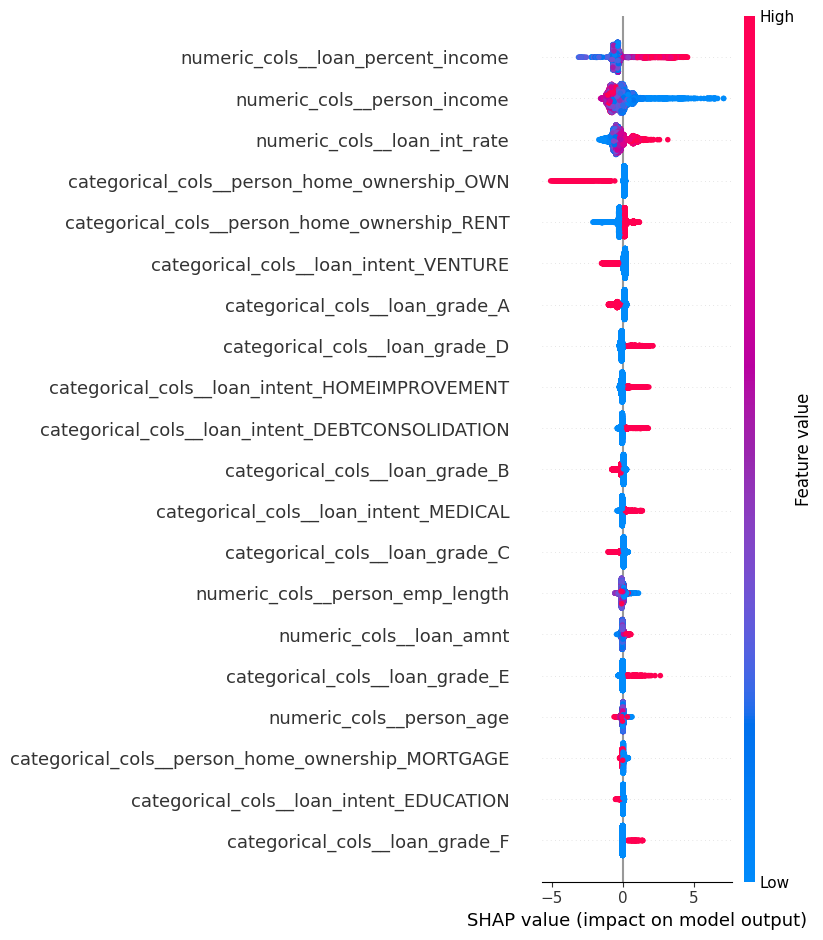

In [96]:
shap.summary_plot(shap_values, X_test_df)

## 16.2 Local Explaination

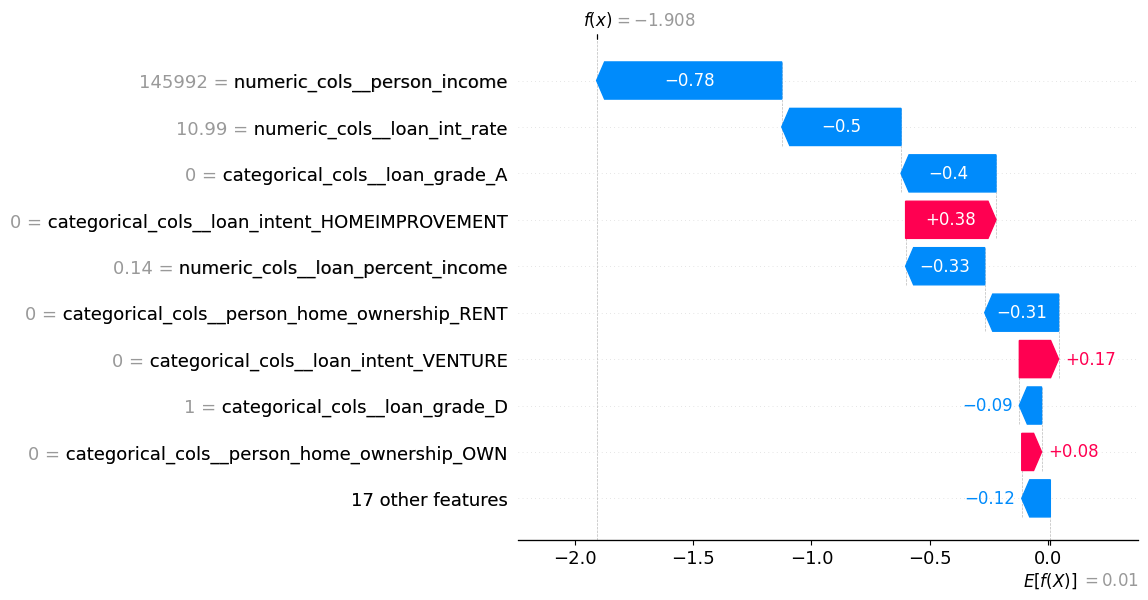

In [97]:
# Pick One row
row_index = 4

# Draw a waterfall plot showing how each feature pushed the feature up or down
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values  = explainer.expected_value,
        data = X_test_df.iloc[5],
    )
)


# 17. Analyze the false positives and false negatives

In [98]:
# Get the predictions from the best performing XGBoost model on the test dataset.
y_pred = xgb_random_search.predict(X_test)

In [99]:
# Create a dataframe to compare the predicted values and actual values.
result_df = X_test.copy()
result_df['actual'] = y_test
result_df['predicted'] = y_pred

In [100]:
FP = result_df[(result_df['actual'] == 0) & (result_df['predicted'] == 1)]
FN = result_df[(result_df['actual'] == 1) & (result_df['predicted'] == 0)]

In [101]:
print(f'False Positive : {len(FP)}')
print(f'False Negative : {len(FN)}')

False Positive : 370
False Negative : 396


# 18. Save Model

In [102]:
joblib.dump(calibration_model, 'Model.pkl')

['Model.pkl']

In [108]:
joblib.dump(best_threshold, 'threshold.pkl')

['threshold.pkl']